In [1]:
from google.colab import drive
import os
import pandas as pd

drive.mount('/content/drive')

Mounted at /content/drive



--- File-level Split ---

Happy:
  Train: 6 files
  Test : 2 files

Neutral:
  Train: 6 files
  Test : 2 files

Sad:
  Train: 6 files
  Test : 2 files

Anxiety:
  Train: 6 files
  Test : 2 files

--- Loading Training Data ---
Loaded Happy1.md.bp.csv → 80 samples
Loaded Happy2.md.bp.csv → 61 samples
Loaded Happy3.md.bp.csv → 79 samples
Loaded Happy4.md.bp.csv → 61 samples
Loaded Happy5.md.bp.csv → 59 samples
Loaded Happy6.md.bp.csv → 65 samples
Loaded Neutral1.md.bp.csv → 60 samples
Loaded Neutral2.md.bp.csv → 60 samples
Loaded Neutral3.md.bp.csv → 53 samples
Loaded Neutral4.md.bp.csv → 40 samples
Loaded Neutral5.md.bp.csv → 47 samples
Loaded Neutral6.md.bp.csv → 40 samples
Loaded Sad1.md.bp.csv → 85 samples
Loaded Sad2.md.bp.csv → 79 samples
Loaded Sad3.md.bp.csv → 81 samples
Loaded Sad4.md.bp.csv → 99 samples
Loaded Sad5.md.bp.csv → 88 samples
Loaded Sad6.md.bp.csv → 64 samples
Loaded Anxiety1.md.bp.csv → 78 samples
Loaded Anxiety2.md.bp.csv → 71 samples
Loaded Anxiety3.md.bp.csv → 9

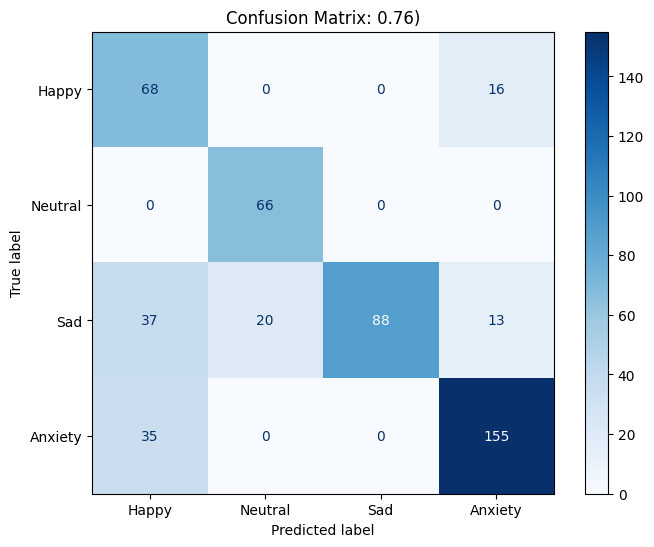

In [4]:
import os
import numpy as np
import pandas as pd
import csv
import warnings
import matplotlib.pyplot as plt
from scipy.signal import medfilt

from sklearn.preprocessing import RobustScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    confusion_matrix,
    precision_recall_fscore_support,
    accuracy_score,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

# config
DATA_DIR = "/content/drive/MyDrive/Latest Emotion Data/Final Data"

CLASSES = ["Happy", "Neutral", "Sad", "Anxiety"]

LABEL_MAP = {
    "Happy": 0,
    "Neutral": 1,
    "Sad": 2,
    "Anxiety": 3
}

# number of frames used for temporal context
CONTEXT_WINDOW = 5

# read eeg file with unknown header row
def read_eeg_file_smart(file_path):
    header_row_index = None
    with open(file_path, "r", encoding="utf-8", errors="replace") as f:
        reader = csv.reader(f)
        for i, row in enumerate(reader):
            row_str = ",".join(row)
            if "POW." in row_str and "Timestamp" in row_str:
                header_row_index = i
                break

    if header_row_index is None:
        return None

    return pd.read_csv(file_path, header=header_row_index, low_memory=False)


# # split eeg files by class into training and testing sets
def file_level_split():
    train_files, test_files = [], []
    print("\n--- File-level Split ---")

    for cls in CLASSES:
        files = sorted(
            f for f in os.listdir(DATA_DIR)
            if f.startswith(cls) and "md.bp.csv" in f
        )

        split_idx = 6 if len(files) >= 8 else int(len(files) * 0.75)

        train_files.extend(files[:split_idx])
        test_files.extend(files[split_idx:split_idx + 2])

        print(f"\n{cls}:")
        print(f"  Train: {len(files[:split_idx])} files")
        print(f"  Test : {len(files[split_idx:split_idx + 2])} files")

    return train_files, test_files


# create temporal context windows
def create_context_windows(data, window_size=5):
    if len(data) < window_size:
        return np.array([])

    pad = window_size // 2
    padded_data = np.pad(data, ((pad, pad), (0, 0)), mode="edge")

    windows = []
    for i in range(pad, len(padded_data) - pad):
        window = padded_data[i - pad : i + pad + 1].flatten()
        windows.append(window)

    return np.array(windows)

# load dataset
def load_dataset(file_list):
    X, y = [], []

    for file in file_list:
        df = read_eeg_file_smart(os.path.join(DATA_DIR, file))
        if df is None:
            continue

        pow_cols = [c for c in df.columns if str(c).startswith("POW.")]
        if not pow_cols:
            continue

        pow_df = (
            df[pow_cols]
            .apply(pd.to_numeric, errors="coerce")
            .dropna(how="any")
        )

        if pow_df.empty:
            continue

        stacked = create_context_windows(pow_df.values, CONTEXT_WINDOW)
        if len(stacked) == 0:
            continue

        X.append(stacked)

        label = next(k for k in LABEL_MAP if file.startswith(k))
        y.append(np.full(len(stacked), LABEL_MAP[label]))

        print(f"Loaded {file} → {len(stacked)} samples")

    if not X:
        return None, None

    return np.vstack(X), np.concatenate(y)

# main pipeline
train_files, test_files = file_level_split()

print("\n--- Loading Training Data ---")
X_train, y_train = load_dataset(train_files)

print("\n--- Loading Testing Data ---")
X_test, y_test = load_dataset(test_files)

if X_train is None:
    raise RuntimeError("No valid training data loaded")

if X_test is None:
    from sklearn.model_selection import train_test_split
    X_train, X_test, y_train, y_test = train_test_split(
        X_train, y_train, test_size=0.2, shuffle=False
    )

# scale features
scaler = RobustScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# train svm
svm = SVC(
    kernel="rbf",
    C=50,
    gamma="scale",
    class_weight="balanced",
    random_state=42
)

print("\nTraining SVM...")
svm.fit(X_train, y_train)
print("Model trained successfully")

# final results
print("\n--- Final Results ---")

y_pred_raw = svm.predict(X_test)
y_pred_smooth = medfilt(y_pred_raw, kernel_size=5)

cm = confusion_matrix(y_test, y_pred_smooth)
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred_smooth, labels=range(len(CLASSES))
)
overall_acc = accuracy_score(y_test, y_pred_smooth)

class_accuracies = []
for i in range(len(CLASSES)):
    tp = cm[i, i]
    fp = cm[:, i].sum() - tp
    fn = cm[i, :].sum() - tp
    tn = cm.sum() - (tp + fp + fn)
    class_accuracies.append((tp + tn) / cm.sum())

print(f"{'':<10} {'Accuracy':<10} {'Precision':<10} {'Recall':<10} {'F1-Score':<10}")
for i, label in enumerate(CLASSES):
    print(
        f"{label:<10} "
        f"{class_accuracies[i]:<10.2f} "
        f"{precision[i]:<10.2f} "
        f"{recall[i]:<10.2f} "
        f"{f1[i]:<10.2f}"
    )

print(f"\nOverall Model Accuracy: {overall_acc:.2f}")

# plot confusion matrix
fig, ax = plt.subplots(figsize=(8, 6))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASSES)
disp.plot(cmap=plt.cm.Blues, values_format="d", ax=ax)
ax.set_title(f"Confusion Matrix: {overall_acc:.2f})")
plt.show()

In [18]:
import joblib
from google.colab import files
import os
import datetime

print("Saving EEG Emotion Recognition SVM model...")

first_file = train_files[0]
df_first = read_eeg_file_smart(os.path.join(DATA_DIR, first_file))
feature_columns = [c for c in df_first.columns if str(c).startswith("POW.")]

artifact = {
    "model": svm,
    "scaler": scaler,
    "classes": CLASSES,
    "label_map": LABEL_MAP,
    "context_window": CONTEXT_WINDOW,
    "train_files": train_files,
    "test_files": test_files,
    "feature_columns": feature_columns,
    "metrics": {
        "confusion_matrix": cm,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "overall_accuracy": overall_acc,
        "class_accuracies": class_accuracies
    },
    "y_pred_raw": y_pred_raw,
    "y_pred_smooth": y_pred_smooth,
    "saved_at": datetime.datetime.now().isoformat()
}

filename = "eeg_emotion_svm_model.pkl"
joblib.dump(artifact, filename)
print(f"Model saved as {filename}")

files.download(filename)

Saving EEG Emotion Recognition SVM model...
Model saved as eeg_emotion_svm_model.pkl


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>